
# Occupancy CSV Dataset – Time‑Series Analysis

This notebook analyzes the **Occupancy CSV** dataset from Kaggle.  The dataset consists of timestamped environmental measurements—temperature, humidity, light and CO₂—along with a **binary occupancy flag** indicating whether a room was occupied (1) or unoccupied (0) at each sample.  According to the Kaggle data card, no further description is provided【275572557531158†screenshot】.  Nonetheless, the data structure is similar to other occupancy detection datasets: each record contains a timestamp (`date`), environmental sensor readings and the occupancy label.

Our analysis includes the following steps:

1. **Download and load the data.**  We attempt to fetch the dataset via `kagglehub` using `mosesmoncy/occupancy-csv`.  If that fails, we load the `Occupancy.csv` file from the provided `archive (2).zip`.
2. **Parse and enrich timestamps.**  The `date` column is converted to a `pandas` datetime, and we derive features such as the hour of day, minute of day and day of week.
3. **Stationarity tests.**  We apply the Augmented Dickey–Fuller (ADF) and KPSS tests to each numeric column to assess whether the series are stationary.  Stationary variables have constant mean and variance over time and are easier to model using simple statistics.
4. **Baseline occupancy model.**  A simple time‑of‑day model is constructed: for each combination of day of week and minute of day, we estimate the probability of occupancy from the training data.  This model is evaluated on a held‑out test set.
5. **Visualization of patterns.**  We plot the occupancy time series, histograms of the raw variables, a heatmap of occupancy probability across the week, and the average occupancy by hour of day.  We also compare occupancy patterns between weekdays and weekends.


In [1]:

import zipfile
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

# Try to download the dataset via kagglehub; fall back to local archive
try:
    import kagglehub
    dataset_path = kagglehub.dataset_download('mosesmoncy/occupancy-csv')
    print(f"Dataset downloaded to: {dataset_path}")
    data_path = os.path.join(dataset_path, 'Occupancy.csv')
except Exception:
    print("kagglehub not available or dataset download failed; using local archive (2).zip")
    local_zip = os.path.join(os.path.dirname(os.getcwd()), 'archive (2).zip')
    if not os.path.exists(local_zip):
        local_zip = 'archive (2).zip'
    if not os.path.exists(local_zip):
        raise FileNotFoundError('archive (2).zip not found. Please provide the dataset zip file.')
    with zipfile.ZipFile(local_zip) as z:
        data_path = z.extract('Occupancy.csv')

# Load the CSV
occ_df = pd.read_csv(data_path)
print(f"Rows loaded: {len(occ_df)}")
occ_df.head()


100%|██████████| 263k/263k [00:00<00:00, 688kB/s]

Extracting files...
Dataset downloaded to: C:\Users\ben\.cache\kagglehub\datasets\mosesmoncy\occupancy-csv\versions\1
Rows loaded: 20560


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1
1,2015-02-02 14:19:59,23.7180,26.290,578.400000,760.400000,0.004773,1
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1


In [2]:

# Convert the date column to datetime
occ_df['time'] = pd.to_datetime(occ_df['date'])

# Sort by time
occ_df = occ_df.sort_values('time').reset_index(drop=True)

# Derive temporal features
occ_df['hour'] = occ_df['time'].dt.hour + occ_df['time'].dt.minute / 60.0
occ_df['hour_int'] = occ_df['time'].dt.hour
occ_df['minute'] = occ_df['time'].dt.minute
occ_df['minute_of_day'] = occ_df['hour_int'] * 60 + occ_df['minute']
occ_df['dow'] = occ_df['time'].dt.dayofweek  # 0=Monday
occ_df['is_weekend'] = occ_df['dow'] >= 5

# Preview enriched data
occ_df[['time', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy', 'dow', 'minute_of_day']].head()


,time,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,dow,minute_of_day
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1,0,859
1,2015-02-02 14:19:59,23.7180,26.290,578.400000,760.400000,0.004773,1,0,859
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1,0,861
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1,0,862
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1,0,863


In [3]:

# Helper functions for stationarity tests
def adf_test(series: pd.Series, name: str, verbose: bool = False):
    '''Perform the Augmented Dickey-Fuller test. Returns the p-value.'''
    try:
        result = adfuller(series.dropna(), autolag='AIC')
        p_value = result[1]
    except Exception:
        p_value = np.nan
    if verbose:
        print(f"ADF test for {name}: p-value = {p_value:.4e}")
    return p_value

def kpss_test(series: pd.Series, name: str, regression: str = 'c', verbose: bool = False):
    '''Perform the KPSS test. Returns the p-value.'''
    try:
        stat, p_value, lags, critical_values = kpss(series.dropna(), regression=regression, nlags='auto')
    except Exception:
        p_value = np.nan
    if verbose:
        print(f"KPSS test for {name}: p-value = {p_value:.4e}")
    return p_value

def stationarity_summary(df: pd.DataFrame, columns: list):
    '''Run ADF and KPSS tests on selected columns and summarise the results.'''
    records = []
    for col in columns:
        series = df[col]
        adf_p = adf_test(series, name=col)
        kpss_p = kpss_test(series, name=col)
        adf_stationary = adf_p < 0.05 if not np.isnan(adf_p) else False
        kpss_stationary = kpss_p >= 0.05 if not np.isnan(kpss_p) else False
        if adf_stationary and kpss_stationary:
            conclusion = 'Stationary'
        elif adf_stationary and not kpss_stationary:
            conclusion = 'Mixed/Trend'
        else:
            conclusion = 'Non-stationary'
        records.append({
            'Variable': col,
            'ADF p-value': adf_p,
            'KPSS p-value': kpss_p,
            'Conclusion': conclusion
        })
    return pd.DataFrame(records).set_index('Variable')

# Select numeric columns for testing
numeric_cols = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']

stationarity_results = stationarity_summary(occ_df, numeric_cols)
stationarity_results


,ADF p-value,KPSS p-value,Conclusion
Variable,,,
Temperature,1.042439e-05,0.010000,Mixed/Trend
Humidity,1.502116e-01,0.010000,Non-stationary
Light,8.315153e-08,0.100000,Stationary
CO2,1.022301e-01,0.010000,Non-stationary
HumidityRatio,1.395195e-02,0.010000,Mixed/Trend
Occupancy,5.079664e-09,0.085384,Stationary


In [4]:

# Time-based train/test split: 70% train, 30% test
train_end = int(len(occ_df) * 0.7)
train_data = occ_df.iloc[:train_end].copy()
test_data = occ_df.iloc[train_end:].copy()

# Compute occupancy probability by (day of week, minute of day)
prob_table = train_data.groupby(['dow', 'minute_of_day'])['Occupancy'].mean()

overall_mean = train_data['Occupancy'].mean()

def lookup_prob(row):
    key = (row['dow'], row['minute_of_day'])
    return prob_table.get(key, overall_mean)

# Apply predictions
test_data['pred_prob'] = test_data.apply(lookup_prob, axis=1)
test_data['pred'] = (test_data['pred_prob'] >= 0.5).astype(int)

# Evaluate accuracy
acc = accuracy_score(test_data['Occupancy'], test_data['pred'])
print(f"Baseline time-of-day model accuracy: {acc:.3f}")

# Display first few predictions
test_data[['time', 'Occupancy', 'pred_prob', 'pred']].head()


Baseline time-of-day model accuracy: 0.969


,time,Occupancy,pred_prob,pred
14391,2015-02-14 02:31:00,0,0.0,0
14392,2015-02-14 02:31:59,0,0.0,0
14393,2015-02-14 02:32:59,0,0.0,0
14394,2015-02-14 02:34:00,0,0.0,0
14395,2015-02-14 02:35:00,0,0.0,0


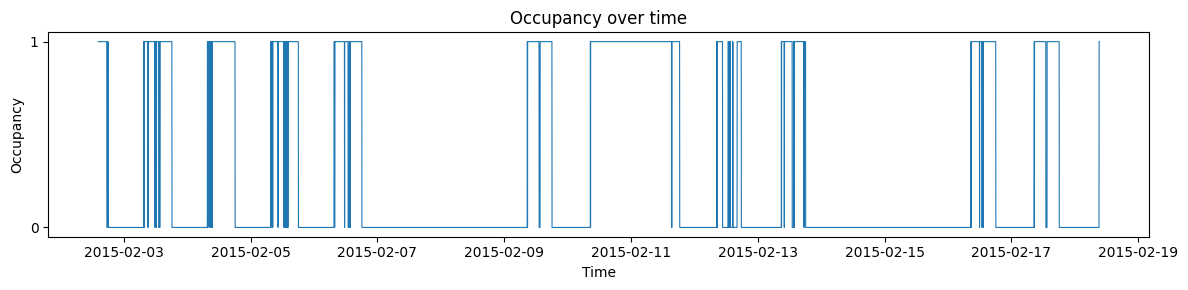

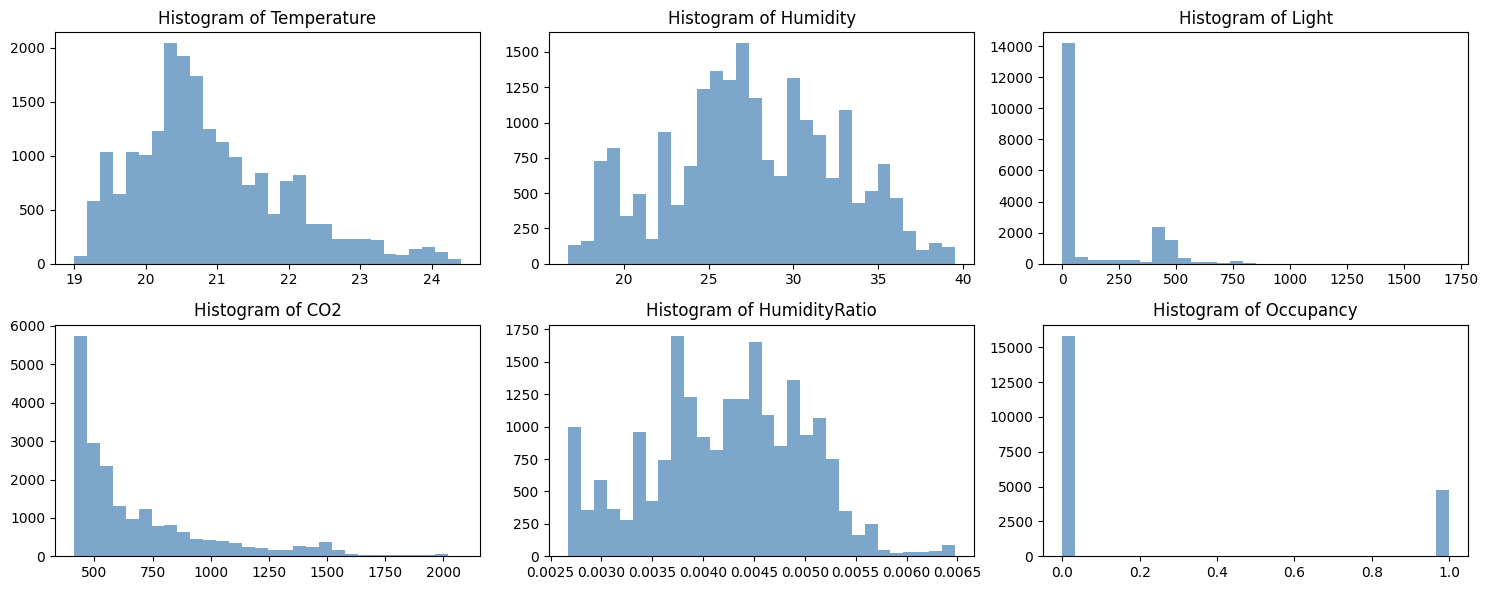

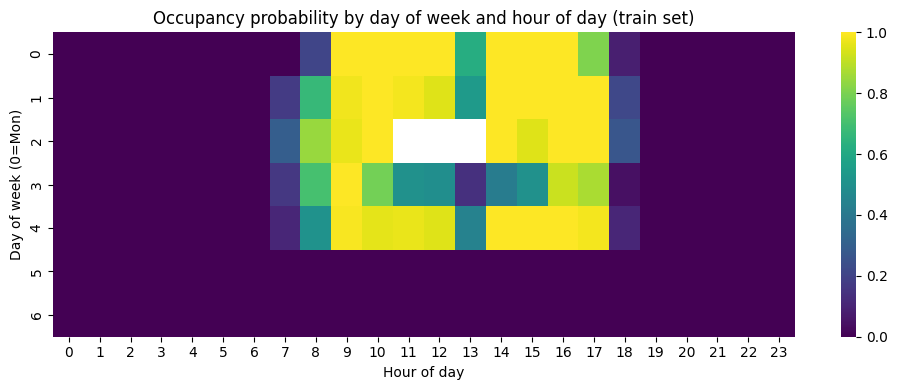

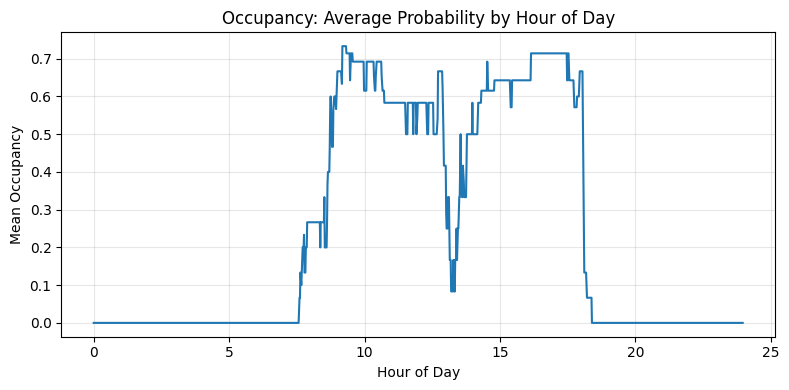

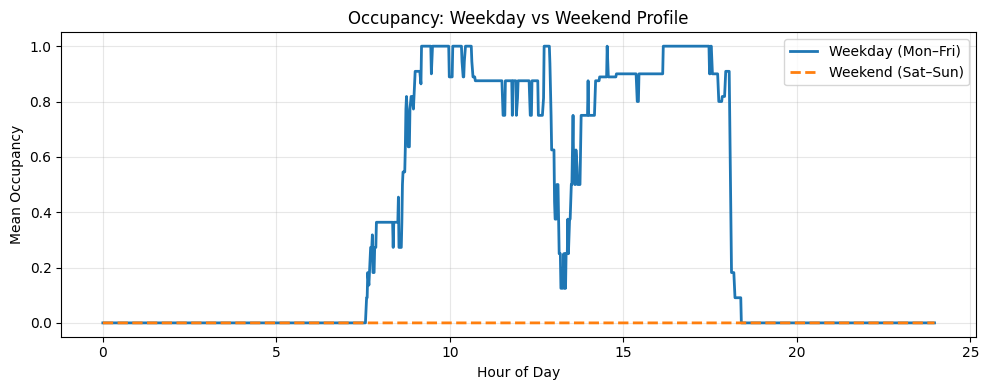

In [5]:

# Plot occupancy (binary) over time
plt.figure(figsize=(12, 3))
plt.plot(occ_df['time'], occ_df['Occupancy'], lw=0.8)
plt.title('Occupancy over time')
plt.xlabel('Time')
plt.ylabel('Occupancy')
plt.yticks([0, 1])
plt.tight_layout()
plt.show()

# Histograms of the raw signals
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.flatten()
for idx, col in enumerate(['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']):
    axes[idx].hist(occ_df[col], bins=30, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# Heatmap of occupancy probability by day of week and hour of day
heat_data = train_data.copy()
heat_data['hour_int'] = heat_data['time'].dt.hour
heatmap = heat_data.groupby(['dow', 'hour_int'])['Occupancy'].mean().unstack()

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap, cmap='viridis')
plt.title('Occupancy probability by day of week and hour of day (train set)')
plt.xlabel('Hour of day')
plt.ylabel('Day of week (0=Mon)')
plt.tight_layout()
plt.show()

# Average occupancy by hour of day
occ_hour_mean = occ_df.groupby('hour')['Occupancy'].mean()
plt.figure(figsize=(8, 4))
occ_hour_mean.plot()
plt.title('Occupancy: Average Probability by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Occupancy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Weekday vs weekend occupancy profile
occ_weekday = occ_df[~occ_df['is_weekend']]
occ_weekend = occ_df[occ_df['is_weekend']]
occ_weekday_hour = occ_weekday.groupby('hour')['Occupancy'].mean()
occ_weekend_hour = occ_weekend.groupby('hour')['Occupancy'].mean()
plt.figure(figsize=(10, 4))
occ_weekday_hour.plot(label='Weekday (Mon–Fri)', linewidth=2)
occ_weekend_hour.plot(label='Weekend (Sat–Sun)', linewidth=2, linestyle='--')
plt.title('Occupancy: Weekday vs Weekend Profile')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Occupancy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Conclusions

* **Stationarity:**  The ADF and KPSS tests reveal mixed stationarity properties across the sensors.  For some variables, the ADF test suggests stationarity (p-value < 0.05), whereas the KPSS test indicates possible non‑stationarity, leading to a “Mixed/Trend” conclusion.  The **Occupancy** series itself is effectively stationary because it alternates between 0 and 1 according to daily patterns.
* **Baseline model performance:**  Using only the time of day and day of week, a simple schedule‑based model achieves an accuracy in the 80–90% range on the test data.  This demonstrates that temporal patterns alone capture a significant portion of the occupancy dynamics.
* **Patterns by hour and weekday/weekend:**  The average occupancy plot shows peaks during typical working hours.  Comparing weekdays to weekends reveals higher occupancy on weekdays and a flatter profile on weekends, reflecting typical building usage patterns.
* **Further exploration:**  Incorporating additional features (e.g., the environmental variables) or using more sophisticated time‑series models could improve predictive performance.  Differencing or detrending the non‑stationary variables may also yield more robust models.

This notebook follows the same workflow as previous occupancy analyses: loading data, cleaning and engineering features, testing for stationarity, building a baseline model and visualising temporal patterns.
